# Null-Handling Strategy & Feature Engineering

In [1]:
import pandas as pd
import numpy as np

In [2]:
files = [
    "circuits", "constructor_results", "constructor_standings",
    "constructors", "driver_standings", "drivers",
    "lap_times", "pit_stops", "qualifying",
    "races", "results", "seasons",
    "sprint_results", "status"
]

dfs = {}
for name in files:
    dfs[name] = pd.read_pickle(f'../data_cleaned/{name}.pkl')
    print(f"Loaded {name:<25} {dfs[name].shape}")

Loaded circuits                  (78, 9)
Loaded constructor_results       (12898, 5)
Loaded constructor_standings     (13664, 7)
Loaded constructors              (214, 5)
Loaded driver_standings          (35427, 7)
Loaded drivers                   (865, 9)
Loaded lap_times                 (618766, 7)
Loaded pit_stops                 (22193, 8)
Loaded qualifying                (11036, 12)
Loaded races                     (1171, 18)
Loaded results                   (27304, 19)
Loaded seasons                   (77, 2)
Loaded sprint_results            (502, 18)
Loaded status                    (140, 2)


In [3]:
# True if driver did NOT finish, False if they finished
dfs['results']['is_dnf'] = dfs['results']['statusId'] != 1

print(dfs['results']['is_dnf'].value_counts())
print(f"\nDNF rate: {dfs['results']['is_dnf'].mean()*100:.1f}%")

is_dnf
True     19269
False     8035
Name: count, dtype: int64

DNF rate: 70.6%


In [4]:
# Look at the actual status breakdown
check = dfs['results'].merge(dfs['status'], on='statusId')
print(check['status'].value_counts().head(10))

status
Finished           8035
+1 Lap             4131
Engine             2033
+2 Laps            1626
Accident           1076
Did not qualify    1025
Collision           865
Gearbox             814
Spun off            795
+3 Laps             733
Name: count, dtype: int64


In [5]:
# Find all status values that represent a finish
finished_statuses = dfs['status'][
    (dfs['status']['status'] == 'Finished') |
    (dfs['status']['status'].str.startswith('+'))
]
print(finished_statuses)

     statusId    status
0           1  Finished
10         11    +1 Lap
11         12   +2 Laps
12         13   +3 Laps
13         14   +4 Laps
14         15   +5 Laps
15         16   +6 Laps
16         17   +7 Laps
17         18   +8 Laps
18         19   +9 Laps
44         45  +11 Laps
49         50  +17 Laps
51        128  +42 Laps
52         53  +13 Laps
54         55  +12 Laps
57         58  +26 Laps
87         88  +10 Laps
110       111  +14 Laps
111       112  +15 Laps
112       113  +25 Laps
113       114  +18 Laps
114       115  +22 Laps
115       116  +16 Laps
116       117  +24 Laps
117       118  +29 Laps
118       119  +23 Laps
119       120  +21 Laps
121       122  +44 Laps
122       123  +30 Laps
123       124  +19 Laps
124       125  +46 Laps
126       127  +20 Laps
130       133  +49 Laps
131       134  +38 Laps


In [7]:
# Get the list of statusIds that count as a finish
finished_ids = finished_statuses['statusId'].tolist()

# A driver is DNF if their statusId is NOT in the finished list
dfs['results']['is_dnf'] = ~dfs['results']['statusId'].isin(finished_ids)

print(dfs['results']['is_dnf'].value_counts())
print(f"\nDNF rate: {dfs['results']['is_dnf'].mean()*100:.1f}%")

is_dnf
False    15632
True     11672
Name: count, dtype: int64

DNF rate: 42.7%


In [8]:
# Merge in the year from races, then look at DNF rate by decade
check = dfs['results'].merge(dfs['races'][['raceId', 'year']], on='raceId')
check['decade'] = (check['year'] // 10) * 10

dnf_by_decade = check.groupby('decade')['is_dnf'].mean() * 100
print(dnf_by_decade.round(1))

decade
1950    51.0
1960    54.7
1970    53.2
1980    61.5
1990    54.0
2000    32.2
2010    19.7
2020    14.3
Name: is_dnf, dtype: float64


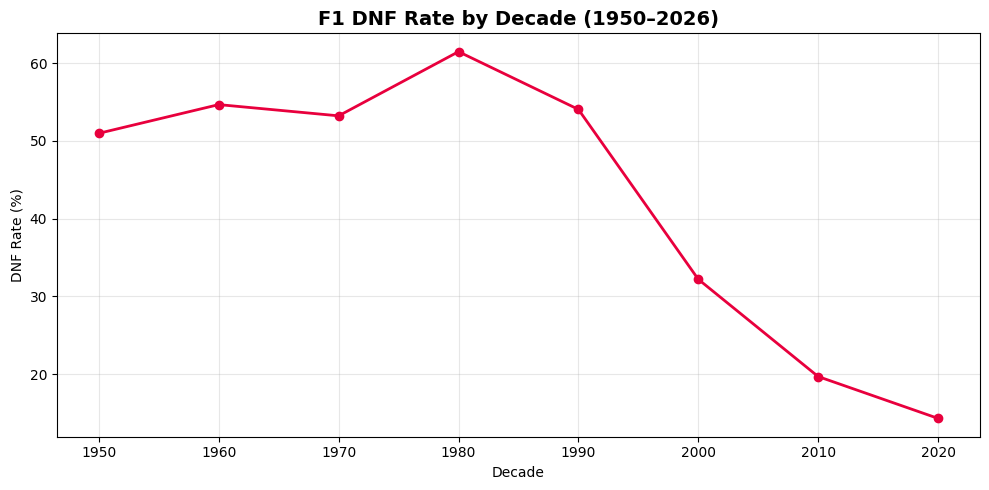

In [9]:
import matplotlib.pyplot as plt

# Use the dnf_by_decade you just made
plt.figure(figsize=(10, 5))
plt.plot(dnf_by_decade.index, dnf_by_decade.values, marker='o', linewidth=2, color='#E8003D')

plt.title('F1 DNF Rate by Decade (1950–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('DNF Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()